## Car Price Prediction with Machine Learning

**Project Objective:** Build a regression model that predicts the selling price of a used car based on features such as brand, age, mileage, fuel type, and transmission.

**Tech Stack:** Python, pandas, scikit-learn, matplotlib, seaborn, Jupyter Notebook

**Feature Checklist:**
- Download a suitable dataset (see Self-Sourcing Guideline below)
- Data cleaning: handle null values, remove duplicates, address inconsistent categorical values (e.g., "Petrol" vs. "petrol")
- Feature engineering: calculate car age from the year column; extract brand from the car name column
- EDA: distribution of selling prices, price vs. fuel type box plots, price vs. car age scatter plot
- Encode categorical variables (One-Hot Encoding or Label Encoding)
- Feature correlation heatmap
- Train/test split
- Train at least 2 regression models (e.g., Linear Regression, Random Forest Regressor, Gradient Boosting)
- Evaluate models using: MAE, RMSE, and R² score
- Feature importance chart for your best-performing model
- All steps in a clean, commented Jupyter Notebook

#### IMPORT THE LIBRARIES

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn import metrics

sns.set_style('whitegrid')

#### LOAD DATASET

In [2]:
# Load The Dataset
cpp = pd.read_csv("car data.csv")

In [3]:
# Check the first five rows of the dataset
cpp.head(5)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
# Check the last five rows of the dataset
cpp.tail(5)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


#### DATA CLEANING AND INVESTIGATION

In [5]:
# Check the shape of the dataset
cpp.shape

(301, 9)

In [6]:
# Check the null values of the dataset
cpp.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [7]:
# Check the important information of the dataset set
cpp.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [8]:
# Counting the number of unique values to identify redundant features
{x: len(cpp[x].unique()) for x in  cpp.columns}

{'Car_Name': 98,
 'Year': 16,
 'Selling_Price': 156,
 'Present_Price': 147,
 'Kms_Driven': 206,
 'Fuel_Type': 3,
 'Seller_Type': 2,
 'Transmission': 2,
 'Owner': 3}

In [9]:
# Going through the statistical values in the dataset 
cpp.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


#### FEATURE ENGINEERING

In [10]:
# Feature Engineering

# Calculate car age
cpp['Car_Age'] = 2026 - cpp['Year']

# Extract car brand from car name
cpp['Brand'] = cpp['Car_Name'].str.split().str[0]
 
# Drop the 'Car_Name' column and create the 'Brand' column
cpp.drop('Car_Name', axis=1, inplace=True)
cpp.head(2)

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12,ritz
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13,sx4


In [11]:
# Drop the 'Year' column
cpp.drop('Year', axis=1, inplace=True)
cpp.head(2)

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12,ritz
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13,sx4


#### EXPLORATORY DATA ANALYSIS

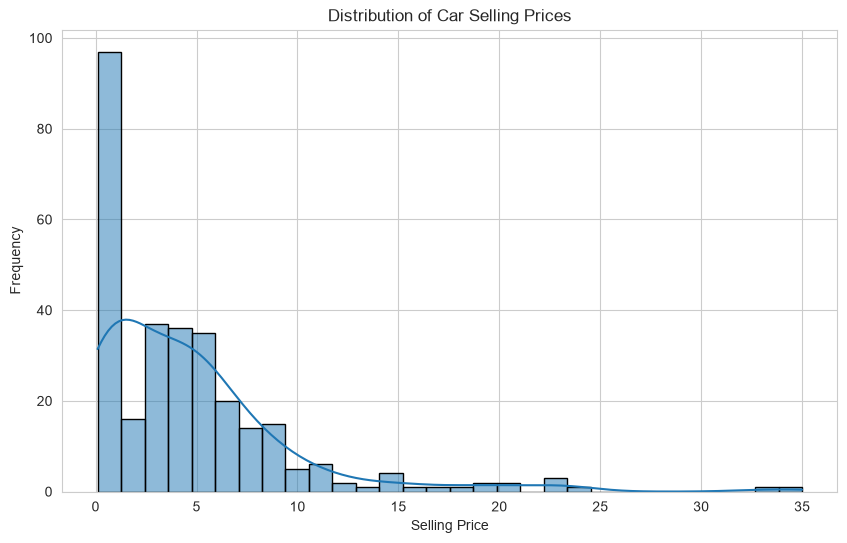

In [12]:
# Distribution of Selling Price
plt.figure(figsize=(10, 6))
sns.histplot(data=cpp, x='Selling_Price', kde=True, bins=30, edgecolor='black')
plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()

- The distribution of car selling prices is **positively (right) skewed.** Most cars are concentrated in the **lower price range,** while relatively few cars have very high selling prices, creating a long tail toward the right. This suggests the dataset contains a small number of **high-priced vehicles or potential outliers.**
- The car selling price distribution shows that most vehicles are sold at relatively low to moderate prices, with only a small number of expensive cars.

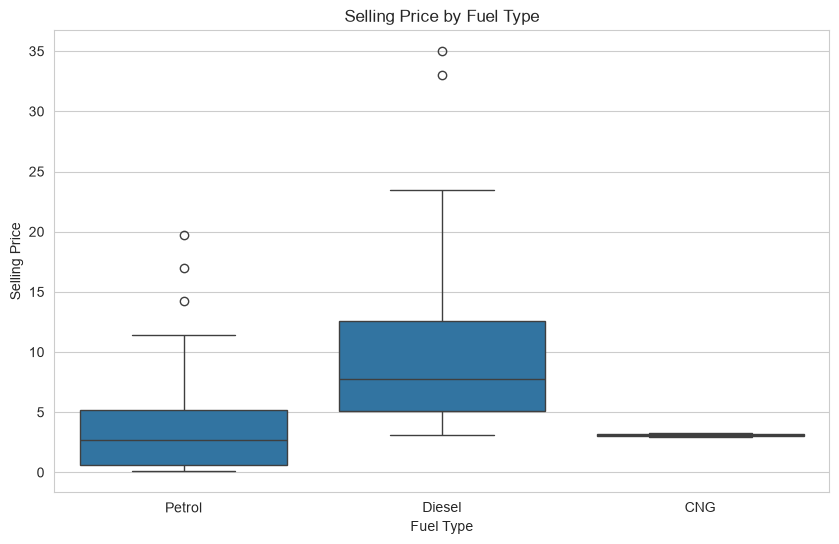

In [13]:
# Selling Price vs Fuel Type
plt.figure(figsize=(10, 6))
sns.boxplot(data=cpp, x='Fuel_Type', y='Selling_Price')
plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.show()

- The box plot shows that **Diesel cars generally have higher selling prices** than Petrol and CNG cars. Diesel vehicles also have the **widest variation in prices** and contain some high-value outliers.
- Petrol cars have relatively lower selling prices with a few outliers, while CNG cars show **low and very little variation** in selling prices.

- The analysis suggests that **fuel type is associated with car selling price,** with Diesel cars generally commanding higher prices than Petrol and CNG cars. Therefore, **fuel type could be an important feature when predicting a car's selling price.**

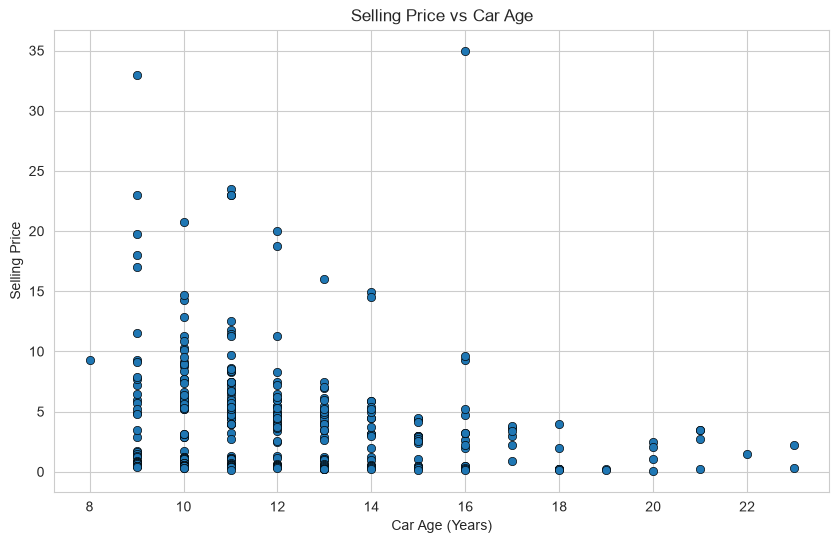

In [14]:
# Selling Price vs Car Age
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cpp, x='Car_Age', y='Selling_Price', edgecolor='black')
plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price')
plt.show()

- The scatter plot shows **a general negative relationship between car age and selling price.** Newer cars tend to have higher selling prices, while older cars are mostly concentrated at lower prices. A few unusually high-priced cars are also visible as outliers.
- The analysis suggests that **selling price generally decreases as a car gets older.** Therefore, **car age is an important feature for predicting selling price,** although other factors may also influence the value of individual vehicles.

#### LABEL ENCODING

In [15]:
# Drop the 'Brand' column. I don't see the brand as important for the model
cpp.drop('Brand', axis=1, inplace=True)

In [16]:
# label Encoding the categorical features manually
encoder = LabelEncoder()
# encoding 'Fuel type' column
cpp.replace({'Fuel_Type': {'Petrol' : 0, 'Diesel' : 1, 'CNG' : 2}}, inplace = True)

# encoding 'Seller Type' column
cpp.replace({'Seller_Type': {'Dealer' : 0, 'Individual' : 1}}, inplace = True)

# encoding 'Transmission' column
cpp.replace({'Transmission': {'Manual' : 0, 'Automatic' : 1}}, inplace = True)

cpp.head(2)

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,0,0,0,0,12
1,4.75,9.54,43000,1,0,0,0,13


#### FEATURE CORRELATION HEATMAP

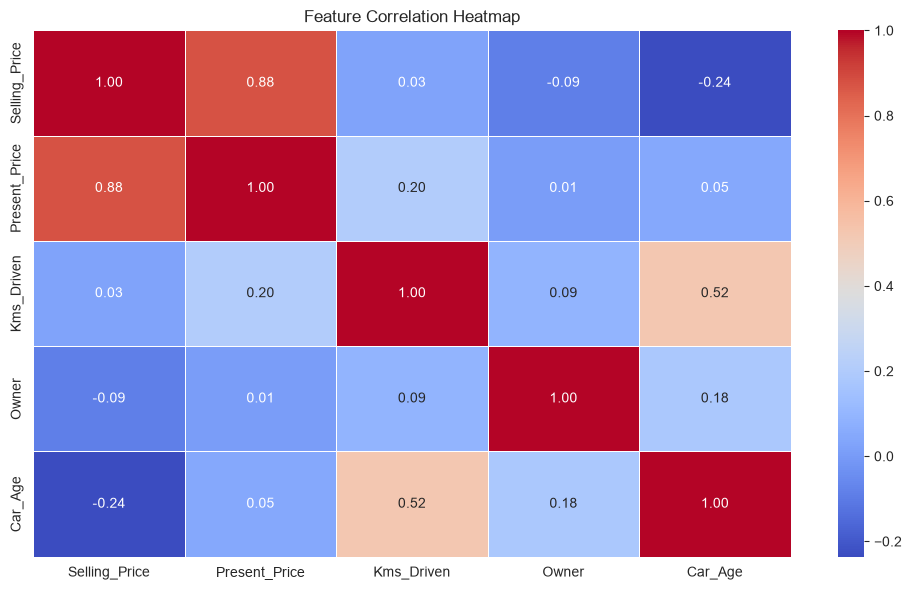

In [17]:
# Select only numerical columns
cpp_corr = cpp.select_dtypes(include=['int64', 'float64'])
# Calculate the correlation matrix
correlation_matrix = cpp_corr.corr()
# Create the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

- The correlation heatmap shows that **Present Price has a strong positive correlation (0.88) with Selling Price,** indicating that cars with higher present prices generally have higher selling prices. **Car Age has a weak negative correlation (-0.24)** with Selling Price, while **Kms Driven (0.03)** and **Owner (-0.09)** show very weak relationships with Selling Price.
- The analysis indicates that **Present Price is the strongest numerical predictor of Selling Price** among the variables shown. Car Age also has some influence, with older cars generally selling for less, while Kms Driven and Owner appear to have relatively little linear relationship with Selling Price.

#### TRAIN TEST SPLIT

In [18]:
# Splitting the dataset into (x) and (y)
X = cpp.drop('Selling_Price', axis= 1)
Y = cpp['Selling_Price']

In [19]:
# Splitting the training data and test data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 0.1, random_state = 2)

### MODEL TRAINING

#### 1 LINEAR REGRESSION

In [20]:
# loading the Linear Regression model
Lin_model = LinearRegression()

In [21]:
# Fit the model
Lin_model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 0.44,-0. , 1.76,..., 1.51,-0.87,-0.41]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Present_Price','Kms_Driven','Fuel_Type',...,'Transmission','Owner', 'Car_Age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.481
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [22]:
# Predicton on the training data
Train_data_predict = Lin_model.predict(X_train)
Train_r2_lr = metrics.r2_score(Y_train, Train_data_predict)
Train_mae_lr = metrics.mean_absolute_error(Y_train, Train_data_predict)
Train_rmse_lr = np.sqrt(metrics.mean_squared_error(Y_train, Train_data_predict))

print('R2_score', Train_r2_lr)
print('Mae', Train_mae_lr)
print('Rmse', Train_rmse_lr)

R2_score 0.8799451660493707
Mae 1.216617409391891
Rmse 1.805278599914456


In [23]:
# Predicton on the testing data
Test_data_predict = Lin_model.predict(X_test)
Test_r2_lr = metrics.r2_score(Y_test, Test_data_predict)
Test_mae_lr = metrics.mean_absolute_error(Y_test, Test_data_predict)
Test_rmse_lr = np.sqrt(metrics.mean_squared_error(Y_test, Test_data_predict))

print('R2_score', Test_r2_lr)
print('Mae', Test_mae_lr)
print('Rmse', Test_rmse_lr)

R2_score 0.8365766715024981
Mae 1.151638215662277
Rmse 1.466332131198915


#### 2 RANDOM FOREST REGRESSOR

In [24]:
# loading the Random Forest Regressor model
Ran_model = RandomForestRegressor(n_estimators = 100, random_state =2)

In [25]:
# Fit the model
Ran_model.fit(X_train, Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",2
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of

In [26]:
# Predicton on the training data
Train_data_predict = Ran_model.predict(X_train)
Train_r2_rfr = metrics.r2_score(Y_train, Train_data_predict)
Train_mae_rfr = metrics.mean_absolute_error(Y_train, Train_data_predict)
Train_rmse_rfr = np.sqrt(metrics.mean_squared_error(Y_train, Train_data_predict))

print('R2_score', Train_r2_rfr)
print('Mae', Train_mae_rfr)
print('Rmse', Train_rmse_rfr)

R2_score 0.9887457272100154
Mae 0.23728888888888883
Rmse 0.5527301147067197


In [27]:
# Predicton on the testing data
Test_data_predict = Ran_model.predict(X_test)
Test_r2_rfr = metrics.r2_score(Y_test, Test_data_predict)
Test_mae_rfr = metrics.mean_absolute_error(Y_test, Test_data_predict)
Test_rmse_rfr = np.sqrt(metrics.mean_squared_error(Y_test, Test_data_predict))

print('R2_score', Test_r2_rfr)
print('Mae', Test_mae_rfr)
print('Rmse', Test_rmse_rfr)

R2_score 0.9807522738145914
Mae 0.33688064516129046
Rmse 0.5032282823863831


#### FEATURE IMPORTANCE CHART

In [28]:
# Feature importance for Random Forest Regressor
feature_importance_ran = pd.DataFrame({'feature' : X.columns, 'importance' : Ran_model.feature_importances_}).sort_values(by = 'importance', ascending=False)
print(feature_importance_ran)

         feature  importance
0  Present_Price    0.882845
6        Car_Age    0.081445
1     Kms_Driven    0.024604
2      Fuel_Type    0.004186
4   Transmission    0.004055
3    Seller_Type    0.002484
5          Owner    0.000380


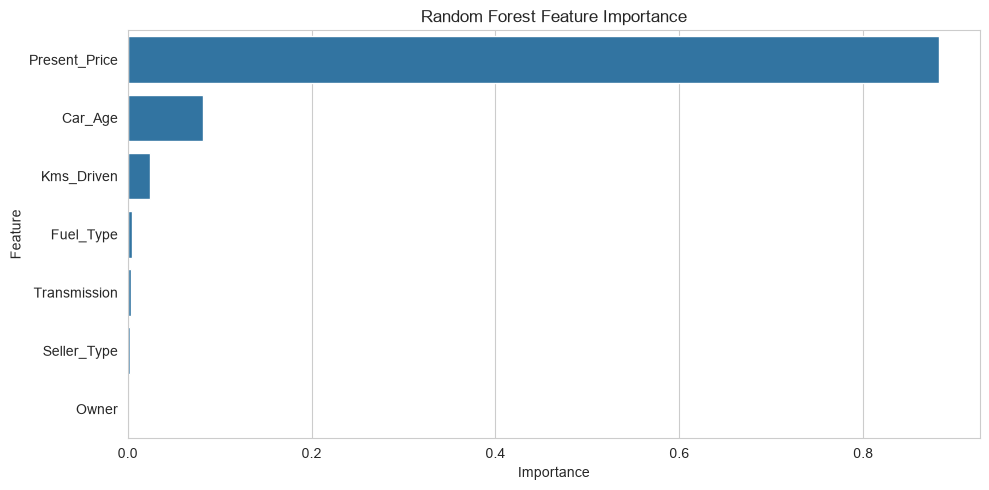

In [29]:
# Feature importance chart visualization
plt.figure(figsize=(10, 5))
sns.barplot(data=feature_importance_ran, x='importance', y='feature')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

- The Random Forest feature importance chart shows that **Present Price is by far the most influential feature,** contributing the majority of the model’s predictive power. **Car Age** is the second most important feature, followed by **Kms Driven**. Fuel Type, Transmission, Seller Type, and Owner have comparatively very low importance.
- The analysis indicates that the **current market price (Present Price) is the strongest factor in predicting a car’s selling price,** while Car Age provides additional predictive information. Overall, the Random Forest model relies primarily on these features when estimating Selling Price.

In [30]:
# Model Comparison
print('Linear Regression', ':', Test_r2_lr)
print('Random Forest Regressor', ':', Test_r2_rfr)

Linear Regression : 0.8365766715024981
Random Forest Regressor : 0.9807522738145914


##### The above model comparison clearly shows that the best performing model 
##### is the Random Forest Regressor model.